# Initialisation
Import base libraries used throughout all the stages

In [1]:
import numpy as np
import pandas as pd
import re
import json

# Preprocessing

In [2]:
DATA_PATH = "listings.csv"
df = pd.read_csv(DATA_PATH)

VALID_TIME_FRAMES = ["ltm", "l30d", "ly"]
AMENITY_INDICATORS = [
    "Wifi",
    "Kitchen",
    "Air conditioning",
    "Washer",
    "Heating",
    "Parking",
    "Self check-in"
]
REVIEW_COLUMNS = [
    "rating",
    "accuracy",
    "cleanliness",
    "checkin",
    "communication",
    "location",
    "value"
]

We define three function that will preprocess specific attributes. 

`categorise_review_scores` discretise the reviews columns, holding a continuous numberical between 0 and 5, into categories 'Low, Medium, High'. This is done through finding the quartiles of the original set of values, and categorising any values <Q1 as 'Low', within the IQR as 'Medium', and >Q3 as 'High'. Rows without associated values are set as 'Missing'.

`frequency_of_reviews` discretise the number of reviews columns, categorising them into 'Low, Medium, High'. Similarily as before, the quartiles are found and the rows are catergorised accordingly using the same process as before.

`amenity_indicators` takes the `amenities` column, and categorises it into one of the Boolean values True or False depending on whether it contains a specific amenity (eg. wifi) within the `amenities` string.

In [3]:
def categorise_review_scores(df, review_column):
    from_column = "review_scores_" + review_column
    to_column = "review_category_" + review_column

    df = df.copy()
    data = df[from_column]

    # Calculate the first and third quartile from the original column
    Q1 = np.nanpercentile(data, 25)
    Q3 = np.nanpercentile(data, 75)

    Q3_taken = min(5.0, Q3)

    # Categorise the original review column into Low, Medium, High, according to calculated quartiles, and place it into a new column
    df[to_column] = pd.cut(
        df[from_column],
        bins=[-float("inf"), Q1, Q3_taken, float("inf")],
        labels=["Low", "Medium", "High"],
        right=False   # fix: bins include lower bounds, this also affect Q1
    )

    # Fill in the missing values for the categorised column
    df[to_column] = df[to_column].cat.add_categories('Missing')
    df[to_column] = df[to_column].fillna("Missing")

    return df


In [4]:
def frequency_of_reviews(df, time_frame = ""):
    df = df.copy()

    # Categorise 'number_of_reviews'
    if time_frame == "":
        number_of_reviews = df["number_of_reviews"]
        category_name = "review_frequency"

    # Categroise other number of reviews columns
    elif time_frame in VALID_TIME_FRAMES:
        number_of_reviews = df["number_of_reviews_" + time_frame]
        category_name = "review_frequency_" + time_frame
    else:
        # This should never happen
        raise ValueError("Invalid time frame")

    # Calculate percentiles, without accounting for listings with 0 reviews
    Q1 = np.nanpercentile(number_of_reviews[number_of_reviews > 0], 25)
    Q3 = np.nanpercentile(number_of_reviews[number_of_reviews > 0], 75)

    # Create a new column to categorise
    df[category_name] = pd.cut(
        number_of_reviews,
        bins=[-float("inf"), 0, Q1, Q3, float("inf")],
        labels=["No Reviews","Low", "Medium", "High"]
    )

    return df

In [5]:
def amenity_indicators(df):
    df = df.copy()

    for amenity in AMENITY_INDICATORS:
        column_name = "has_" + amenity.lower().replace(" ", "_")

        # Create a new column determining whether each listing has our desired amenity
        df[column_name] = df["amenities"].apply(
            lambda x: bool(re.search(amenity, str(x), re.IGNORECASE))
        )

    return df

We pass on our dataframe to each of the functions, to include columns including our processed values.

In [6]:
df = pd.read_csv(DATA_PATH)

# Discretise the review columns
for column in REVIEW_COLUMNS:
    df = categorise_review_scores(df, column)

# Categorise the 'number_of_reviews' column
df = frequency_of_reviews(df)

# Categorise all other number of reviews columns
for time_frame in VALID_TIME_FRAMES:
    df = frequency_of_reviews(df, time_frame)

# Determine if certain amenities exist
df = amenity_indicators(df)

Finally, we save the processed data into a seperate csv file.

In [7]:
df.to_csv("processed_data.csv", index=False)

# Correlation Analysis

In [8]:
import numpy as np
import pandas as pd
import json
from scipy.stats import pearsonr, spearmanr
from itertools import combinations
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.metrics import normalized_mutual_info_score

DATA_PATH = "processed_data.csv"   # output of preprocessing_2.py, NOT processed_only.csv

AMENITY_INDICATORS = [
    "Wifi", "Kitchen", "Air conditioning", "Washer", "Heating", "Parking", "Self check-in"
]
REVIEW_FREQ_ORDER = ["No Reviews", "Low", "Medium", "High"]

DISCRETE_KINDS = {"discrete", "ordinal"}


df = pd.read_csv(DATA_PATH)
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

We process some basic data to use during correlation

In [9]:
# Creating an amenity count column from preproccessed data
has_cols = ["has_" + a.lower().replace(" ", "_") for a in AMENITY_INDICATORS]
df["amenity_count"] = df[has_cols].sum(axis=1)

# Reading in review frequency data and converting to an ordered categorical variable
df["review_frequency"] = pd.Categorical(
    df["review_frequency"], categories=REVIEW_FREQ_ORDER, ordered=True
).codes.astype(float)
df.loc[df["review_frequency"] < 0, "review_frequency"] = np.nan

variables = {"review_scores_rating": ("review_scores_rating", "continuous"),
    "price": ("price", "continuous"),
    "amenity_count": ("amenity_count", "discrete"),
    "host_listings_count": ("host_listings_count", "discrete"),
    "review_frequency": ("review_frequency", "ordinal")}

df = df.dropna(subset=list(variables.keys()))

We define a function for mutual information.

In [10]:
def mutual_information(x, y, kind_x, kind_y):
    """MI WITHOUT binning, using nearest-neighbour estimators"""
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=float)
    if kind_y == "ordinal":
        return mutual_info_classif(x, y.astype(int), discrete_features=False, random_state=42)[0]
    if kind_x == "ordinal":
        return mutual_info_classif(y.reshape(-1, 1), x.ravel().astype(int),
                                   discrete_features=False, random_state=42)[0]
    return mutual_info_regression(x, y, discrete_features=False, random_state=42)[0]

For every pair of variables, we calculate the correlation using pearson, spearman, and mutual information.

In [11]:
results = []
for v1, v2 in combinations(variables, 2):
    kind1 = variables[v1][1]
    kind2 = variables[v2][1]

    # Pearson correlation
    pearson_corr, _ = pearsonr(df[v1], df[v2])

    # Spearman correlation
    spearman_corr, _ = spearmanr(df[v1], df[v2])
        
    # Mutual Information
    mi = mutual_information(df[v1], df[v2], kind1, kind2)
 
    # NMI: needs discrete labels, so only computed when BOTH variables are
    # already discrete
    if kind1 in DISCRETE_KINDS and kind2 in DISCRETE_KINDS:
        nmi = round(float(normalized_mutual_info_score(df[v1], df[v2])), 4)
    else:
        nmi = None
        
   
    print(f"Correlation between {v1} and {v2}")
    print(f"  Pearson: {pearson_corr:.4f}")
    print(f"  Spearman: {spearman_corr:.4f}")
    print(f"  Mutual Information: {mi:.4f}")
    print(f"  Normalized Mutual Information: {'n/a (continuous variable)' if nmi is None else f'{nmi:.4f}'}\n")

    results.append({
        "var_1": v1,
        "var_2": v2,
        "pearson": round(pearson_corr, 4),
        "spearman": round(spearman_corr, 4),
        "mutual_information": round(float(mi), 4),
        "normalized_mutual_information": nmi,
    })

Correlation between review_scores_rating and price
  Pearson: 0.0292
  Spearman: 0.0921
  Mutual Information: 0.0218
  Normalized Mutual Information: n/a (continuous variable)

Correlation between review_scores_rating and amenity_count
  Pearson: 0.0792
  Spearman: 0.0212
  Mutual Information: 0.0170
  Normalized Mutual Information: n/a (continuous variable)

Correlation between review_scores_rating and host_listings_count
  Pearson: -0.2168
  Spearman: -0.2783
  Mutual Information: 0.1276
  Normalized Mutual Information: n/a (continuous variable)

Correlation between review_scores_rating and review_frequency
  Pearson: 0.2052
  Spearman: -0.0937
  Mutual Information: 0.3589
  Normalized Mutual Information: n/a (continuous variable)

Correlation between price and amenity_count
  Pearson: 0.0339
  Spearman: 0.2511
  Mutual Information: 0.0637
  Normalized Mutual Information: n/a (continuous variable)

Correlation between price and host_listings_count
  Pearson: -0.0160
  Spearman: 0.057

We save the results

In [12]:
with open("correlation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved results to correlation_results.json")

Saved results to correlation_results.json


# Supervised Learning

In [13]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

DATA_PATH = 'processed_data.csv'
 
Y_COL = 'review_category_rating'
X_COLS = ['host_listings_count', 'latitude', 'longitude', 'accommodates',
          'number_of_reviews', 'availability_365', 'reviews_per_month', 'host_has_profile_pic',
          'hosts_time_as_user_years', 'host_is_superhost', 'host_identity_verified',
          'has_wifi', 'has_kitchen', 'has_air_conditioning', 'has_washer', 'has_heating',
          'has_parking', 'has_self_check-in', 'review_frequency', 'price']

BOOL = ['host_is_superhost', 'host_identity_verified', 'host_has_profile_pic',]
CAT = ['review_frequency', 'has_wifi', 'has_kitchen', 'has_air_conditioning', 'has_washer', 'has_heating',
          'has_parking', 'has_self_check-in']
STR = ['price']
 
FILTER_CATEGORIES = ['Missing']

TEST_SPLIT = 0.2

KNN_N_NEIGHBORS = 5

df = pd.read_csv(DATA_PATH)

We frist convert non-numberical columns into numerical columns.

Boolean columns turn into 1 or 0. Categorical values get converted into integers, depending on how many categories there are.

The `price` column is also parsed to convert it from a string to a numberical value.

In [14]:
def process_bool(val):
    # Keep NaN values as Nan
    if pd.isna(val):
        return np.nan

    # 1 if True, 0 if False
    if val[0].lower() == 't':
        return 1
    elif val[0].lower() == 'f':
        return 0


# Return the categorical 'number' for the category it is in
def process_cat(cat, cat_dict):
    return cat_dict[cat]



def parse_price(price):
    # Check if the current price is a string
    if not pd.isna(price):
        # Remove the `$` and `,` symbols from the string
        cleaned_price = re.sub(r'[$,]', '', price)
        return (float(cleaned_price))
    else:
        # If price is Nan, just keep it as NaN
        return price

In [15]:
# Process Booelan Values
for column in BOOL:
    df[column] = df[column].apply(process_bool)

# Process Categorical Values
for column in CAT:
    # Get all the unique categories
    categories = list(set(df[column].values))
    cat_dict = {}

    # Give each category an associated integer
    for i in range(len(categories)):
        cat_dict[categories[i]] = i

    df[column] = df[column].apply(process_cat, cat_dict=cat_dict)


# Process price
df['price'] = df['price'].apply(parse_price)


# Filter out the rows with 'missing'
for category in FILTER_CATEGORIES:
    df = df[df[Y_COL] != category]

We split the data into train and test sets. The ratio was chosen to be 80/20. Stratified splitting was used to preserve the ratio between categories.

In [16]:
# Split into train and test sets

X = df[X_COLS]
y = df[Y_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SPLIT,
    stratify=y, # Stratify the split
    random_state=1
)

We fill in missing values with the median, for each column (imputing). We also normalise all values so that they all have a mean of 0 and standard deviation of 1.

In [17]:
def impute_and_scale(X_train, X_test):
    num_cols = X_train.select_dtypes(include='number').columns

    # Impute with median values
    imputer = SimpleImputer(missing_values=np.nan, strategy='median')
    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = imputer.transform(X_test[num_cols]) 

    # Scale the values for each column
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])
 
    return X_train, X_test

# Fill out the missings values (impute), scale the values
X_train, X_test = impute_and_scale(X_train, X_test)

We test different k values for the KNN algorithm. 
We use 5-fold cross validation to test how well our model performs for the chosen k value. The split is also astratified to maintain the ratio between categories during the split.
The highest mean score and the corresponding k is recorded.

In [18]:
def run_knn(X_train, X_test, y_train, y_test):
    k_values = range(1, 200, 5)
    five_f_CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

    best_k = 0
    best_score = -1

    for k in k_values:  
        results = []

        # Split according to 5 fold cross validation
        for train_idx, test_idx in five_f_CV.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]

            # Train (fit) the model
            knn = KNeighborsClassifier(n_neighbors=k)
            knn.fit(X_tr, y_tr)

            # Give our prediciton, and store the accuracy for the current k, for the current fold.
            y_pred = knn.predict(X_val)
            results.append(accuracy_score(y_val, y_pred))

        # Calculate the mean accuracy
        mean_score = np.mean(results)
        print(f"k={k}: mean accuracy = {np.round(mean_score,4)}")

        # Check if the mean accuracy is the best we've seen yet, keep a record of it.
        if mean_score > best_score:
            best_score = mean_score
            best_k = k

    print(f"Best k: {best_k}, score: {best_score}")

    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    best_knn.fit(X_train, y_train)

    return best_knn

knn = run_knn(X_train, X_test, y_train, y_test)

from sklearn.inspection import permutation_importance

k=1: mean accuracy = 0.5852
k=6: mean accuracy = 0.633
k=11: mean accuracy = 0.6499
k=16: mean accuracy = 0.651
k=21: mean accuracy = 0.6574
k=26: mean accuracy = 0.6569
k=31: mean accuracy = 0.6564
k=36: mean accuracy = 0.6553
k=41: mean accuracy = 0.6559
k=46: mean accuracy = 0.6553
k=51: mean accuracy = 0.6554
k=56: mean accuracy = 0.654
k=61: mean accuracy = 0.6552
k=66: mean accuracy = 0.6539
k=71: mean accuracy = 0.6549
k=76: mean accuracy = 0.6544
k=81: mean accuracy = 0.6545
k=86: mean accuracy = 0.6544
k=91: mean accuracy = 0.6541
k=96: mean accuracy = 0.6541
k=101: mean accuracy = 0.6544
k=106: mean accuracy = 0.6542
k=111: mean accuracy = 0.6531
k=116: mean accuracy = 0.6534
k=121: mean accuracy = 0.6535
k=126: mean accuracy = 0.6533
k=131: mean accuracy = 0.6529
k=136: mean accuracy = 0.6531
k=141: mean accuracy = 0.6538
k=146: mean accuracy = 0.6542
k=151: mean accuracy = 0.6536
k=156: mean accuracy = 0.653
k=161: mean accuracy = 0.6539
k=166: mean accuracy = 0.6534
k=171:

We run decision tree at different depths from 1 to 20. We once again use 5-fold Cross Validation to test how well our model performs, and record the the highest mean accuracy, and the depth that gives it.

In [19]:
def run_decision_tree(X_train, X_test, y_train, y_test):
    depth_values = range(1, 21)
    n = 5
    nf_CV = StratifiedKFold(n_splits=n, shuffle=True, random_state=1)

    best_depth = 0
    best_score = -1

    for depth in depth_values:
        results = []

        # Split our train set according to 5 fold cross validation
        for train_idx, test_idx in nf_CV.split(X_train, y_train):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[test_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[test_idx]


            # Train and predict for the current fold. Calculate the accuracy and keep a record of it
            dt = DecisionTreeClassifier(max_depth=depth, random_state=1)
            dt.fit(X_tr, y_tr)

            y_pred = dt.predict(X_val)
            results.append(accuracy_score(y_val, y_pred))

        # Calculate the mean accuracy
        mean_score = np.mean(results)
        print(f"max_depth={depth}: mean accuracy = {np.round(mean_score,4)}")

        # Check if the mean accuracy is the best we've seen yet, and keep track of it.
        if mean_score > best_score:
            best_score = mean_score
            best_depth = depth

    print(f"\nBest max_depth: {best_depth}, score: {np.round(best_score,4)}")

    best_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
    best_dt.fit(X_train, y_train)

    return best_dt

dt = run_decision_tree(X_train, X_test, y_train, y_test)

max_depth=1: mean accuracy = 0.641
max_depth=2: mean accuracy = 0.641
max_depth=3: mean accuracy = 0.65
max_depth=4: mean accuracy = 0.6686
max_depth=5: mean accuracy = 0.6721
max_depth=6: mean accuracy = 0.6812
max_depth=7: mean accuracy = 0.6735
max_depth=8: mean accuracy = 0.6701
max_depth=9: mean accuracy = 0.6671
max_depth=10: mean accuracy = 0.6574
max_depth=11: mean accuracy = 0.6554
max_depth=12: mean accuracy = 0.6471
max_depth=13: mean accuracy = 0.6371
max_depth=14: mean accuracy = 0.6323
max_depth=15: mean accuracy = 0.6259
max_depth=16: mean accuracy = 0.6185
max_depth=17: mean accuracy = 0.614
max_depth=18: mean accuracy = 0.6083
max_depth=19: mean accuracy = 0.6063
max_depth=20: mean accuracy = 0.6051

Best max_depth: 6, score: 0.6812


Using permutation feature imoprtance, we figure out the importance, that is, how much a feature affects the prediction, for each KNN and Decision Tree.

In [20]:
def permutation_feature_importance(model, X_test, y_test, feature_names, name, n_repeats=10):
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=n_repeats,
        random_state=1,
        scoring='accuracy'
    )

    importances = pd.Series(result.importances_mean, index=feature_names)
    importances = importances.sort_values(ascending=False)

    print(f"Feature importances {name}:")
    print(importances)


permutation_feature_importance(knn, X_test, y_test, X_train.columns, 'KNN')
permutation_feature_importance(dt, X_test, y_test, X_train.columns, 'Decision Tree')

Feature importances KNN:
review_frequency            0.109715
host_is_superhost           0.025853
reviews_per_month           0.016349
host_listings_count         0.015973
number_of_reviews           0.013761
availability_365            0.009574
hosts_time_as_user_years    0.007551
has_heating                 0.006187
has_kitchen                 0.004964
host_identity_verified      0.004564
longitude                   0.004446
accommodates                0.003434
has_washer                  0.002964
latitude                    0.002541
host_has_profile_pic        0.001670
has_parking                 0.001200
has_self_check-in           0.000518
has_air_conditioning        0.000494
price                       0.000188
has_wifi                   -0.000282
dtype: float64
Feature importances Decision Tree:
number_of_reviews           0.222889
host_listings_count         0.035921
host_is_superhost           0.021830
review_frequency            0.014161
reviews_per_month           0.011950


We calculate the per-class precision for both our models.

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)

    print(f"{name}")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

evaluate('KNN', knn, X_test, y_test)
evaluate('Decision Tree', dt, X_test, y_test)

KNN
              precision    recall  f1-score   support

        High       0.65      0.58      0.61      1098
         Low       0.54      0.35      0.42      1004
      Medium       0.70      0.85      0.77      2149

    accuracy                           0.66      4251
   macro avg       0.63      0.59      0.60      4251
weighted avg       0.65      0.66      0.65      4251

[[ 638  101  359]
 [ 223  349  432]
 [ 122  196 1831]]
Decision Tree
              precision    recall  f1-score   support

        High       0.65      0.68      0.66      1098
         Low       0.59      0.26      0.36      1004
      Medium       0.71      0.87      0.78      2149

    accuracy                           0.68      4251
   macro avg       0.65      0.60      0.60      4251
weighted avg       0.66      0.68      0.65      4251

[[ 747   69  282]
 [ 244  260  500]
 [ 162  112 1875]]


We create a baseline to compare our supervised models against. The baseline 'model' is simply picking the most frequently occuring category.

We also calculate the bootstrap confidence interval for the KNN algorithm, which gives out an itnerval estimate for our test accuracy.

In [22]:
def baseline(X_train, X_test, y_train, y_test):
    # Define our baseline model, which is simply guessing the most frequent category.
    dummy = DummyClassifier(strategy='most_frequent')
    dummy.fit(X_train, y_train)

    # Calculate the accuracy of the baseline model
    y_pred = dummy.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    print(f"Baseline (majority class) accuracy: {np.round(score,4)}")

    return score


def bootstrap_ci(model, X_test, y_test, n_iterations=1000):
    # Our initial prediction
    y_pred_full = model.predict(X_test)
    correct = (y_pred_full == y_test.values).astype(int)

    n = len(correct)
    scores = []

    # Take random samples and check get the mean of the 1s and 0 (corrects and incorrects)
    for i in range(n_iterations):
        idx = np.random.choice(n, size=n, replace=True)
        scores.append(correct[idx].mean())

    # Calculate the 95% confidence interval from our scores
    scores = np.array(scores)
    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    print(f"Bootstrap 95% CI: [{lower:.4f}, {upper:.4f}] (mean={scores.mean():.4f})")

In [23]:
# Baseline
baseline_score = baseline(X_train, X_test, y_train, y_test)

knn_test_score = accuracy_score(y_test, knn.predict(X_test))
dt_test_score = accuracy_score(y_test, dt.predict(X_test))

print(f"\nKNN test accuracy: {np.round(knn_test_score,4)} (baseline: {np.round(baseline_score,4)}")
print(f"Decision Tree test accuracy: {np.round(dt_test_score,4)} (baseline: {np.round(baseline_score,4)})")

bootstrap_ci(knn, X_test, y_test)

Baseline (majority class) accuracy: 0.5055

KNN test accuracy: 0.6629 (baseline: 0.5055
Decision Tree test accuracy: 0.678 (baseline: 0.5055)
Bootstrap 95% CI: [0.6488, 0.6768] (mean=0.6628)


We save our predictions to a seperate CSV file names `predictoins.csv`.

In [24]:
path='predictions.csv'
models = {'knn': knn, 'decision_tree': dt}


output = pd.DataFrame(index=X_test.index)
output['actual'] = y_test

for name, model in models.items():
    output[f'predicted_{name}'] = model.predict(X_test)

output.to_csv(path, index=True)

# Feature Selection

First we use a filter method (Decision Tree). We get the top 3 important features, using our best Decision Tree model found in the Supervised Learning section.

In [25]:
from sklearn.feature_selection import mutual_info_classif
import warnings

In [26]:
TOP_N = 3

importances = pd.Series(dt.feature_importances_, index=X_COLS).sort_values(ascending=False)

print(f"Rows used: {len(df)} (train {len(X_train)}, test {len(X_test)})")
print("Decision Tree feature importances (sum to 1):")
print(importances.round(4).to_string())
print(f"\nTop {TOP_N} features (embedded, Decision Tree):")
for rank, (feat, val) in enumerate(importances.head(TOP_N).items(), start=1):
    print(f"  {rank}. {feat}: {val:.4f}")

importances.rename("tree_importance").round(5).to_csv("decision_tree_importances.csv")
print("\nSaved decision_tree_importances.csv")

Rows used: 21251 (train 17000, test 4251)
Decision Tree feature importances (sum to 1):
number_of_reviews           0.6848
host_is_superhost           0.1441
host_listings_count         0.0901
reviews_per_month           0.0243
price                       0.0132
hosts_time_as_user_years    0.0118
longitude                   0.0090
latitude                    0.0080
availability_365            0.0059
review_frequency            0.0055
host_has_profile_pic        0.0014
accommodates                0.0013
has_heating                 0.0005
has_wifi                    0.0000
has_kitchen                 0.0000
has_air_conditioning        0.0000
has_washer                  0.0000
has_parking                 0.0000
has_self_check-in           0.0000
host_identity_verified      0.0000

Top 3 features (embedded, Decision Tree):
  1. number_of_reviews: 0.6848
  2. host_is_superhost: 0.1441
  3. host_listings_count: 0.0901

Saved decision_tree_importances.csv


In [27]:
warnings.filterwarnings('ignore')

BINARY_AMENITY = ['has_wifi', 'has_kitchen', 'has_air_conditioning', 'has_washer',
                  'has_heating', 'has_parking', 'has_self_check-in']

SEED = 1

# Filter method: Mutual Information
#Seperates the discrete and continuous features for mutual information calculation
discrete_mask = [col in (BOOL + BINARY_AMENITY + ['review_frequency']) for col in X_COLS]

 # Calculates the mutual information scores for each feature and prints the top 3 features based on mutual information and decision tree importance
mi_arr = mutual_info_classif(X_train, y_train, discrete_features=discrete_mask, random_state=SEED)
mi_scores = pd.Series(mi_arr, index=X_train.columns)

top3_filter = mi_scores.sort_values(ascending=False).head(3)
top3_embedded = importances.head(TOP_N)

print("Top 3 (filter — Mutual Information):")
print(top3_filter.round(4))
print("\nTop 3 (embedded — Decision Tree importance):")
print(top3_embedded.round(4))

Top 3 (filter — Mutual Information):
number_of_reviews    0.2622
review_frequency     0.2090
reviews_per_month    0.1364
dtype: float64

Top 3 (embedded — Decision Tree importance):
number_of_reviews      0.6848
host_is_superhost      0.1441
host_listings_count    0.0901
dtype: float64


# Clustering & Principle Component Analysis

We import libraries and define constants.

The constant K is our ideal K for k-means clustering. This value was found via the elbow method, which will be shown in this section below.

In [28]:
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# Defined variables -------------------------------------------------------
FEATURE_SETS = {
    "Geographic": [
        "latitude",
        "longitude",
        "amenity_count",
        "accommodates"
    ],
    
    "Price-tier": [
        "price",
        "accommodates",
        "bedrooms",
        "review_scores_rating"
    ],
    
    "Host operating profile": [
        "host_listings_count",
        "availability_365",
        "review_scores_rating"
    ],
    
    "Custom listing characteristics": [
        "price",
        "accommodates",
        "bedrooms",
        "amenity_count",
        "availability_365"
    ]
}

AMENITY_COLUMNS = [
    "has_wifi",
    "has_kitchen",
    "has_air_conditioning",
    "has_washer",
    "has_heating",
    "has_parking"
]

CLUSTER_FEATURES = [
    "price_log",
    "accommodates",
    "bedrooms",
    "amenity_count",
    "availability_365"
]

K = 6 # This K value was found via the elbow method, which will be shown.

DATA_PATH = "processed_data.csv"
df = pd.read_csv(DATA_PATH)

We convert some categories into numberical values.

In [29]:
# Price processing
if not pd.api.types.is_numeric_dtype(df["price"]):
    df["price"] = pd.to_numeric(
        df["price"].astype(str).str.replace(r"[$,]", "", regex=True),
        errors="coerce"
    )

# Handles t/f text flags as well as booleans, missing counts as absent
df[AMENITY_COLUMNS] = (
    df[AMENITY_COLUMNS]
    .replace({"t": 1, "f": 0})
    .fillna(0)
    .astype(int)
)
df["amenity_count"] = df[AMENITY_COLUMNS].sum(axis=1)

# log1p keeps zero prices valid
df["price_log"] = np.log1p(df["price"])

We compare summary statistics and missing values of each candidate set in order to figure out which candidate feature set we want to use.

Features sets with excessive missing values or unsuitable variables are excluded.

In [30]:
for name, features in FEATURE_SETS.items():
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    print("Features:")
    print(features)
    
    print("\nMissing values:")
    print(df[features].isna().sum())
    
    print("\nSummary statistics:")
    print(df[features].describe())
    
    print()

Geographic
Features:
['latitude', 'longitude', 'amenity_count', 'accommodates']

Missing values:
latitude         0
longitude        0
amenity_count    0
accommodates     0
dtype: int64

Summary statistics:
           latitude     longitude  amenity_count  accommodates
count  25728.000000  25728.000000   25728.000000  25728.000000
mean     -37.825745    145.006937       5.133201      3.767996
std        0.078847      0.155238       0.994339      2.415809
min      -38.270621    144.476171       0.000000      1.000000
25%      -37.851770    144.953948       5.000000      2.000000
50%      -37.817392    144.971770       5.000000      3.000000
75%      -37.799848    145.017133       6.000000      5.000000
max      -37.440386    145.853180       6.000000     16.000000

Price-tier
Features:
['price', 'accommodates', 'bedrooms', 'review_scores_rating']

Missing values:
price                   6553
accommodates               0
bedrooms                4679
review_scores_rating    4477
dtype: in

We create a feature set with out chosen features (defined in the constant `CLUSTER_FEATURES`). We also scale the features, so that the K-means algorithm can calculate distances correctly.

          price_log  accommodates      bedrooms  amenity_count  \
count  16392.000000  16392.000000  16392.000000   16392.000000   
mean       5.587318      4.278306      1.969131       5.219314   
std        0.635525      2.541227      1.115675       0.939009   
min        2.265921      1.000000      0.000000       0.000000   
25%        5.249652      2.000000      1.000000       5.000000   
50%        5.585374      4.000000      2.000000       5.000000   
75%        5.916202      6.000000      2.000000       6.000000   
max       10.049772     16.000000     16.000000       6.000000   

       availability_365  
count      16392.000000  
mean         218.232674  
std          114.402353  
min            0.000000  
25%          110.000000  
50%          232.000000  
75%          331.000000  
max          365.000000  
    price_log  accommodates  bedrooms  amenity_count  availability_365
3   -0.747956     -0.896565 -0.868677       0.831419          0.522447
6    0.157349     -0.896565 -

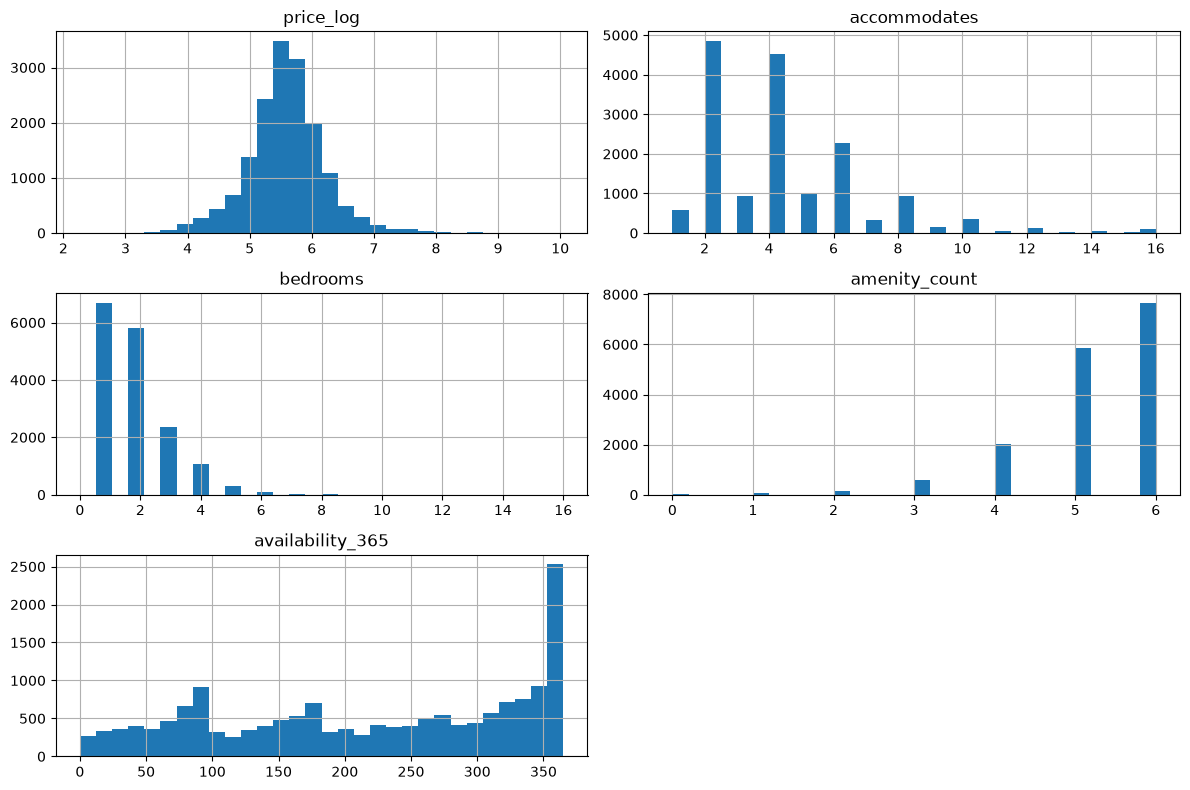

In [31]:
def feature_set(df, features):
    df = df.copy()

    # Creating separate data frame and removing missing values 
    cluster_df = df[features + ["review_scores_rating"]].copy() 
    cluster_df = cluster_df.dropna(subset=features).copy()

    # Visualising distributions for each feature
    print(cluster_df[features].describe())

    # Visualising histograms for each feature
    cluster_df[features].hist(
        figsize=(12, 8),
        bins=30
    )
    plt.tight_layout()

    # Standardising data
    # Creates a comparable scale since k_means uses distance
    X = cluster_df[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_scaled_df = pd.DataFrame(
        X_scaled,
        columns=features,
        index=cluster_df.index
    )

    print(X_scaled_df.head())

    return cluster_df, X_scaled

cluster_df, X_scaled = feature_set(df, CLUSTER_FEATURES)

We try different values of k (2-10), and then plot it so we can visualise where the improvement levels off. That is, we use the elbow method.

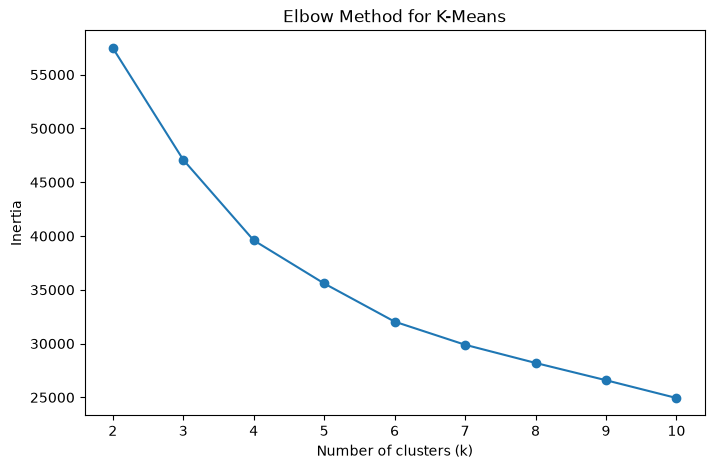

In [32]:
def k_means(X):
    inertias = []

    k_values = range(2, 11)

    for k in k_values:
        
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        # Performs clustering - fits model into k clusters
        kmeans.fit(X)
        
        inertias.append(kmeans.inertia_)

    # Plot results - inertia for each value of k
    # Use this figure to find the elbow, define as variable K 
    plt.figure(figsize=(8, 5))
    plt.plot(
        k_values,
        inertias,
        marker="o"
    )

    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for K-Means")
    plt.xticks(list(k_values))

k_means(X_scaled)

From the elbow method above, the ideal K value was shown to be 6. Hence, we use this K value for clustering. We run both k_means and hierarchial clustering.

In [33]:
# Fit the final k-means model with the chosen K and return a copy of the
# data frame with each row's cluster label in a new kmeans_cluster column
# K is chosen from elbow method and defined above
def final_kmeans(df, X, k):
    df = df.copy()

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    df["kmeans_cluster"] = kmeans.fit_predict(X)

    return df



# Fit hierarchical (Ward) clustering with k clusters and attach the labels
# Adds the resulting cluster assignments to the Airbnb dataframe so they can be compared with the K-means solution
def final_hierarchical(df, X, k):
    df = df.copy()

    hierarchical = AgglomerativeClustering(
        n_clusters=k
    )

    df["hierarchical_cluster"] = hierarchical.fit_predict(X)

    return df

clustered_df = final_kmeans(cluster_df, X_scaled, K)
clustered_df = final_hierarchical(clustered_df, X_scaled, K)

In [34]:
# Summarise each cluster: size, share of listings and average feature values
def describe_clusters(df, features, cluster_col):
    cols = list(dict.fromkeys(features + ["review_scores_rating"]))
    summary = df.groupby(cluster_col)[cols].mean().round(2)

    counts = df[cluster_col].value_counts().sort_index()
    summary["size"] = counts
    summary["percent"] = (counts / counts.sum() * 100).round(2)

    summary["avg_price"] = np.expm1(summary["price_log"]).round(0)

    print(summary)

describe_clusters(clustered_df, CLUSTER_FEATURES, "kmeans_cluster")
describe_clusters(clustered_df, CLUSTER_FEATURES, "hierarchical_cluster")

                price_log  accommodates  bedrooms  amenity_count  \
kmeans_cluster                                                     
0                    5.18          2.41      1.12           5.48   
1                    6.38          9.53      4.26           5.61   
2                    5.86          4.95      2.31           5.55   
3                    5.20          2.40      1.11           5.19   
4                    5.18          2.51      1.26           3.39   
5                    5.79          5.04      2.28           5.51   

                availability_365  review_scores_rating  size  percent  \
kmeans_cluster                                                          
0                         312.79                  4.68  2826    17.24   
1                         231.98                  4.75  1681    10.26   
2                         305.85                  4.74  3657    22.31   
3                          96.02                  4.77  2802    17.09   
4                

In [35]:
# Produces adjusted rand index to compare k_means and hierarchial clustering
def compare_kmeans_hierarchial(df):
    ari = adjusted_rand_score(
        df["kmeans_cluster"],
        df["hierarchical_cluster"]
    )

    print("Adjusted Rand Index:", ari)


    
# Compares review ratings by cluster to investigate relationship
# Visualises differences using a bar graph
# Might wanna fix this (heavily right skewed data)
# Use our low/med/high categories instead somehow?
def compare_ratings_by_cluster(df):
    rating_by_cluster = (
        df
        .groupby("kmeans_cluster")["review_scores_rating"]
        .agg(["mean", "median", "count"])
    )

    print(rating_by_cluster.round(3))

    plt.figure(figsize=(8, 5))

    plt.bar(
        rating_by_cluster.index.astype(str),
        rating_by_cluster["mean"]
    )

    plt.xlabel("K-Means Cluster")
    plt.ylabel("Mean Review Score")
    plt.title("Mean Review Score by K-Means Cluster")

Adjusted Rand Index: 0.48290032711788283
                 mean  median  count
kmeans_cluster                      
0               4.683    4.85   2365
1               4.750    4.86   1439
2               4.736    4.85   3195
3               4.770    4.87   2484
4               4.655    4.83   1383
5               4.772    4.86   3192


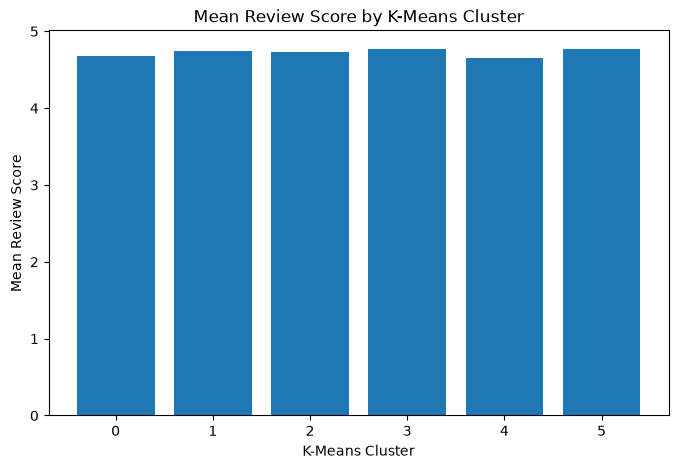

In [36]:
compare_kmeans_hierarchial(clustered_df)
compare_ratings_by_cluster(clustered_df)

We reduce dimensionality via principle component analysis. 

                   PC1   PC2   PC3
price             0.49  0.04 -0.13
accommodates      0.59  0.07 -0.14
bedrooms          0.58  0.10 -0.16
amenity_count     0.28 -0.39  0.88
availability_365 -0.01  0.91  0.41


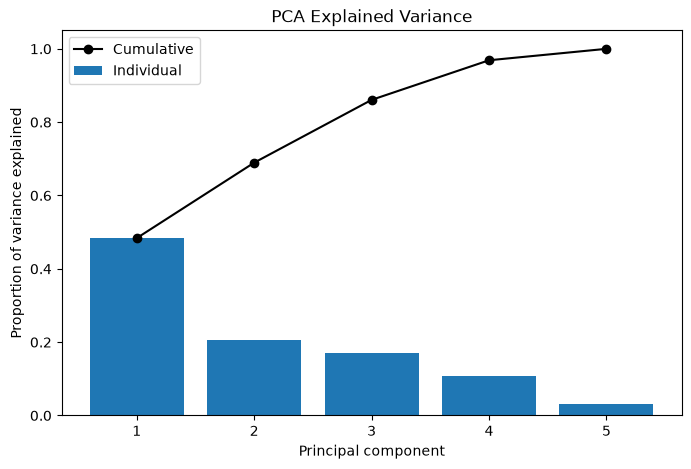

In [37]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

ratios = pca.explained_variance_ratio_
components = np.arange(1, len(ratios) + 1)

plt.figure(figsize=(8, 5))
plt.bar(components, ratios, label="Individual")
plt.plot(
    components,
    np.cumsum(ratios),
    marker="o",
    color="black",
    label="Cumulative"
)

plt.xlabel("Principal component")
plt.ylabel("Proportion of variance explained")
plt.title("PCA Explained Variance")
plt.xticks(components)
plt.legend()

n_components = 3

loadings = pd.DataFrame(
    pca.components_[:n_components].T,
    columns=[f"PC{i + 1}" for i in range(n_components)],
    index=features
).round(2)

print(loadings)

We visualise the clusters on a plot

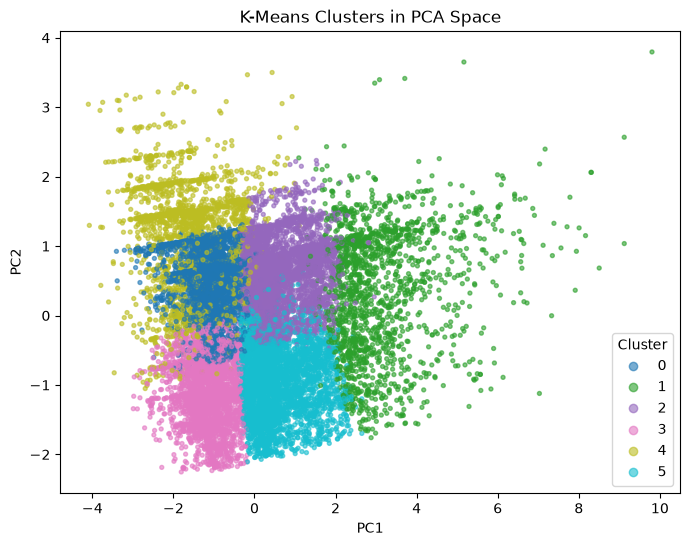

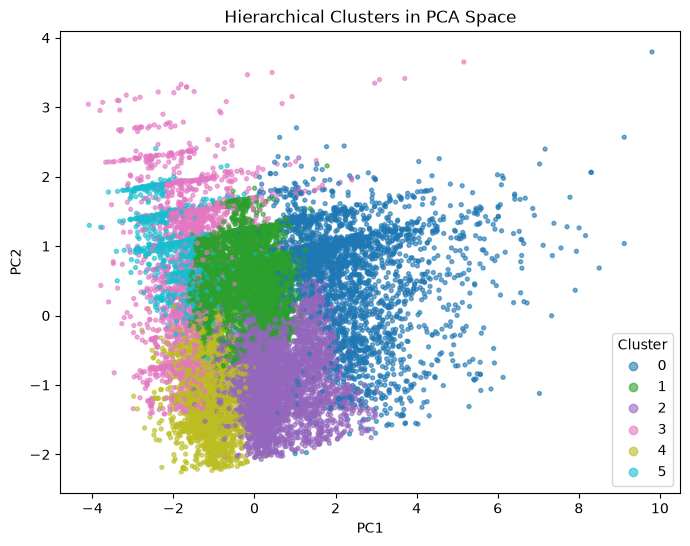

In [38]:
# Plot the first two components coloured by cluster label
def plot_pca_clusters(X_pca, labels, title):
    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        cmap="tab10",
        s=8,
        alpha=0.6
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(title)
    plt.legend(*scatter.legend_elements(), title="Cluster")

plot_pca_clusters(
    X_pca, clustered_df["kmeans_cluster"], "K-Means Clusters in PCA Space"
)
plot_pca_clusters(
    X_pca, clustered_df["hierarchical_cluster"], "Hierarchical Clusters in PCA Space"
)

plt.show()